# Draw optimization flow chart with `graphviz`

---

### 1. **Ensure Graphviz is installed**
Install both Python wrapper and system binary:
```bash
sudo apt-get install graphviz         # Debian/Ubuntu
brew install graphviz                 # macOS
```

---

### 2. **Display in notebook using IPython display (optional)**

Skip this section if not needed

```python
from graphviz import Digraph
from IPython.display import SVG, display

...

# Display in Jupyter
display(SVG(svg_data))
```

In [1]:
from graphviz import Digraph

dot = Digraph(format="svg")
dot.attr(rankdir='TB', fontsize='12', nodesep='0.5', fontname='Arial')

# --- Nodes ---

# Terminal nodes
dot.node("start", "Start", shape="oval")
dot.node("terminate", "Terminate", shape="doublecircle")

# NCG section
dot.node("ncg", "Use NCG with Wolfe Conditions\n(c1, c2)", shape="box")
dot.node("ncg_progress", "NCG makes progress?", shape="diamond")
dot.node("continue_ncg", "Continue with NCG", shape="box")
dot.node("ncg_converged", "Converged?\n(ΔE, ΔF < threshold)", shape="diamond")

# LGD section
dot.node("switch_lgd", "Switch to Local Gradient Descent", shape="box")
dot.node("init_step", "trialStepSize = a0 * lFace * maxForceMag", shape="box")
dot.node("apply_step", "Apply step and compute newEnergy", shape="box")
dot.node("energy_check", "Is newEnergy < oldEnergy?", shape="diamond")
dot.node("magnify_step", "trialStepSize *= lgdMagnifyCoeff", shape="box")
dot.node("reset_step", "trialStepSize *= lgdShrinkCoeff", shape="box")
dot.node("adjust_step", "Reduce step until newEnergy < oldEnergy", shape="box")
dot.node("lgd_converged", "Converged?\n(ΔE, ΔF < threshold)", shape="diamond")
dot.node("interval_check", "Reach step size reset interval?", shape="diamond")


# --- Edges ---

dot.edge("start", "ncg")
dot.edge("ncg", "ncg_progress")
dot.edge("ncg_progress", "continue_ncg", label="Yes")
dot.edge("continue_ncg", "ncg_converged")
dot.edge("ncg_converged", "terminate", label="Yes")
dot.edge("ncg_converged", "ncg", label="No")  # <-- Loop back if not converged

dot.edge("ncg_progress", "switch_lgd", label="No")
dot.edge("switch_lgd", "init_step")
dot.edge("init_step", "apply_step")
dot.edge("apply_step", "energy_check")

dot.edge("energy_check", "lgd_converged", label="Yes")
dot.edge("lgd_converged", "terminate", label="Yes")
dot.edge("lgd_converged", "interval_check", label="No")  # <-- Loop back if not converged

dot.edge("interval_check", "init_step", label="Yes")
dot.edge("interval_check", "magnify_step", label="No")
dot.edge("magnify_step", "apply_step")

dot.edge("energy_check", "reset_step", label="No")
dot.edge("reset_step", "adjust_step")
dot.edge("adjust_step", "lgd_converged")

# --- Render ---
dot.render("energy_optimization_flowchart", cleanup=False)
print("Flowchart rendered as 'energy_optimization_flowchart.svg'")

Flowchart rendered as 'energy_optimization_flowchart.svg'


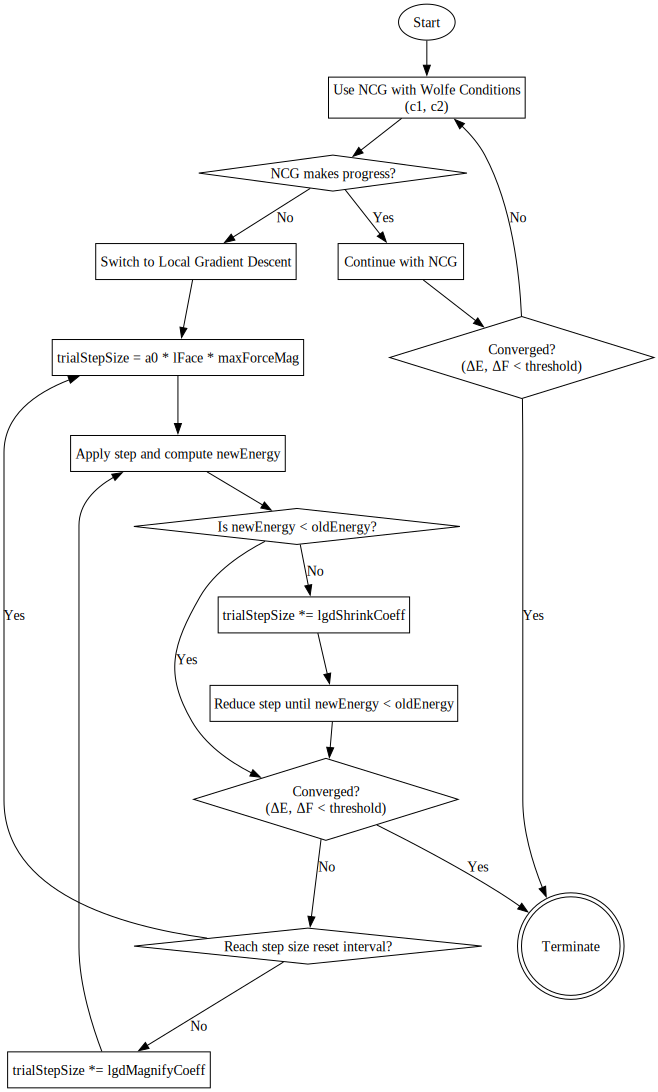

In [2]:
from IPython.display import SVG, display

# Render to SVG string (in-memory, no file written)
svg_data = dot.pipe(format='svg').decode('utf-8')

# Display in Jupyter
display(SVG(svg_data))